In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

imu_data_file_path = r"04_05_2026\xpos\x_pos_default_p1\SensorConnectData__1.csv"
cuaternion_file_path = r"04_05_2026\xpos\x_pos_default_p1\QuaternionEst__1.csv"

In [13]:
def find_csv_header_line(filepath, required_first_col="Time"):
    filepath = Path(filepath)

    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        clean = line.strip()

        if clean.startswith(required_first_col + ","):
            return i

    raise ValueError(
        f"No se encontró una línea de encabezado que empiece con '{required_first_col},'"
    )

In [14]:
def read_generic_sensor_csv(filepath):
    header_line = find_csv_header_line(filepath, required_first_col="Time")

    df = pd.read_csv(
        filepath,
        skiprows=header_line,
        sep=",",
        skipinitialspace=True
    )

    df.columns = [c.strip() for c in df.columns]

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Time"]).copy()
    df = df.sort_values("Time").reset_index(drop=True)

    return df

In [15]:
df_imu_all = read_generic_sensor_csv(imu_data_file_path)
# print(df.columns[:])
# df
cols = ['Time', 'estLinearAccelX', 'estLinearAccelY', 'estLinearAccelZ', 'estAngularRateX', 'estAngularRateY','estAngularRateZ']
df_imu = df_imu_all[cols].copy()
# df_accel.head()
df_imu = df_imu.rename(columns={
    "estLinearAccelX": "alx",
    "estLinearAccelY": "aly",
    "estLinearAccelZ": "alz",
    "estAngularRateX": "agx",
    "estAngularRateY": "agy",
    "estAngularRateZ": "agz"
})
df_imu

,Time,alx,aly,alz,agx,agy,agz
0,1777931639370,-0.001583,-0.000683,0.040660,-0.000529,0.000066,-0.000223
1,1777931639380,0.000282,-0.002229,0.040869,0.000289,0.000312,-0.000161
2,1777931639391,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410
3,1777931639401,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410
4,1777931639419,0.000961,-0.009677,0.032349,-0.000876,0.000885,0.000028
...,...,...,...,...,...,...,...
13111,1777931800324,0.014305,-0.032856,0.039753,-0.001580,0.000508,-0.000197
13112,1777931800342,0.007008,-0.030093,0.053230,-0.000737,-0.000532,0.000792
13113,1777931800352,0.007008,-0.030093,0.053230,-0.000737,-0.000532,0.000792
13114,1777931800364,0.004399,-0.000700,0.047458,-0.000713,-0.000191,-0.000083


In [16]:
df_quat = read_generic_sensor_csv(cuaternion_file_path)
# print(df_quat)
df_quat = df_quat.rename(columns={
    "estOrientQuaternion[0]": "q0",
    "estOrientQuaternion[1]": "q1",
    "estOrientQuaternion[2]": "q2",
    "estOrientQuaternion[3]": "q3"
})
# df_q
df_quat = df_quat[['Time','q0', 'q1', 'q2', 'q3', 'flag']].copy()
df_quat

,Time,q0,q1,q2,q3,flag
0,1777931639370,0.999981,0.001548,0.005987,-0.000009,0
1,1777931639380,0.999981,0.001534,0.005982,-0.000005,0
2,1777931639391,0.999981,0.001532,0.005984,-0.000004,0
3,1777931639401,0.999981,0.001532,0.005984,-0.000004,0
4,1777931639419,0.999982,0.001542,0.005748,0.000091,0
...,...,...,...,...,...,...
13111,1777931800324,0.999667,0.004573,0.006895,0.024424,1
13112,1777931800342,0.999667,0.004567,0.006892,0.024436,1
13113,1777931800352,0.999667,0.004567,0.006892,0.024436,1
13114,1777931800364,0.999667,0.004565,0.006896,0.024437,1


In [17]:
df_merge = {0}
del df_merge

In [18]:
import pandas as pd

# Asegurar que Time sea numérico
df_imu["Time"] = pd.to_numeric(df_imu["Time"], errors="coerce")
df_quat["Time"] = pd.to_numeric(df_quat["Time"], errors="coerce")

# Eliminar filas inválidas
df_imu = df_imu.dropna(subset=["Time"]).copy()
df_quat = df_quat.dropna(subset=["Time"]).copy()

# Ordenar obligatoriamente para merge_asof
df_imu = df_imu.sort_values("Time").reset_index(drop=True)
df_quat = df_quat.sort_values("Time").reset_index(drop=True)

# Tolerancia en nanosegundos
# Ejemplo: 5 ms = 5_000_000 ns
tol_ns = 5_000_000

df_merge = pd.merge_asof(
    df_imu,
    df_quat,
    on="Time",
    direction="nearest",
    tolerance=tol_ns
)

df_merge = df_merge.dropna(subset=["q0", "q1", "q2", "q3"]).reset_index(drop=True)

print(df_merge)

                Time       alx       aly       alz       agx       agy  \
0      1777931639370 -0.001583 -0.000683  0.040660 -0.000529  0.000066   
1      1777931639380  0.000282 -0.002229  0.040869  0.000289  0.000312   
2      1777931639391 -0.001388  0.005071  0.039841 -0.000388  0.000228   
3      1777931639401 -0.001388  0.005071  0.039841 -0.000388  0.000228   
4      1777931639419  0.000961 -0.009677  0.032349 -0.000876  0.000885   
...              ...       ...       ...       ...       ...       ...   
13111  1777931800324  0.014305 -0.032856  0.039753 -0.001580  0.000508   
13112  1777931800342  0.007008 -0.030093  0.053230 -0.000737 -0.000532   
13113  1777931800352  0.007008 -0.030093  0.053230 -0.000737 -0.000532   
13114  1777931800364  0.004399 -0.000700  0.047458 -0.000713 -0.000191   
13115  1777931800374  0.004399 -0.000700  0.047458 -0.000713 -0.000191   

            agz        q0        q1        q2        q3  flag  
0     -0.000223  0.999981  0.001548  0.005987 -

In [19]:
df_merge["timestamp"] = (df_merge["Time"] - df_merge["Time"].iloc[0]) / 1e9
df_merge["timestamp"]

0        0.000000e+00
1        1.000000e-08
2        2.100000e-08
3        3.100000e-08
4        4.900000e-08
             ...     
13111    1.609540e-04
13112    1.609720e-04
13113    1.609820e-04
13114    1.609940e-04
13115    1.610040e-04
Name: timestamp, Length: 13116, dtype: float64

In [20]:
df_merge["dt"] = df_merge["timestamp"].diff()

In [21]:
df_merge[["Time", "timestamp", "dt"]].head()

,Time,timestamp,dt
0,1777931639370,0.000000e+00,NaN
1,1777931639380,1.000000e-08,1.000000e-08
2,1777931639391,2.100000e-08,1.100000e-08
3,1777931639401,3.100000e-08,1.000000e-08
4,1777931639419,4.900000e-08,1.800000e-08


In [22]:
print(df_merge["dt"].describe())

fs_mean = 1 / df_merge["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    1.311500e+04
mean     1.227632e-08
std      2.727559e-09
min      1.000000e-08
25%      1.000000e-08
50%      1.100000e-08
75%      1.400000e-08
max      1.900000e-08
Name: dt, dtype: float64
Frecuencia promedio: 81457603.54 Hz


In [23]:
df_merge.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,q3,flag,timestamp,dt
0,1777931639370,-0.001583,-0.000683,0.040660,-0.000529,0.000066,-0.000223,0.999981,0.001548,0.005987,-0.000009,0,0.000000e+00,NaN
1,1777931639380,0.000282,-0.002229,0.040869,0.000289,0.000312,-0.000161,0.999981,0.001534,0.005982,-0.000005,0,1.000000e-08,1.000000e-08
2,1777931639391,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,-0.000004,0,2.100000e-08,1.100000e-08
3,1777931639401,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,-0.000004,0,3.100000e-08,1.000000e-08
4,1777931639419,0.000961,-0.009677,0.032349,-0.000876,0.000885,0.000028,0.999982,0.001542,0.005748,0.000091,0,4.900000e-08,1.800000e-08


In [24]:
al_values = df_merge[["alx", "aly", "alz"]].values
df_merge["al_norm"] = np.linalg.norm(al_values, axis=1)

ag_values = df_merge[["agx", "agy", "agz"]].values
df_merge["ag_norm"] = np.linalg.norm(ag_values, axis=1)

In [25]:
df_init = df_merge[df_merge["timestamp"] <= 20.0].copy()
df_init

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,q3,flag,timestamp,dt,al_norm,ag_norm
0,1777931639370,-0.001583,-0.000683,0.040660,-0.000529,0.000066,-0.000223,0.999981,0.001548,0.005987,-0.000009,0,0.000000e+00,NaN,0.040697,0.000578
1,1777931639380,0.000282,-0.002229,0.040869,0.000289,0.000312,-0.000161,0.999981,0.001534,0.005982,-0.000005,0,1.000000e-08,1.000000e-08,0.040931,0.000455
2,1777931639391,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,-0.000004,0,2.100000e-08,1.100000e-08,0.040186,0.000609
3,1777931639401,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,-0.000004,0,3.100000e-08,1.000000e-08,0.040186,0.000609
4,1777931639419,0.000961,-0.009677,0.032349,-0.000876,0.000885,0.000028,0.999982,0.001542,0.005748,0.000091,0,4.900000e-08,1.800000e-08,0.033779,0.001246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13111,1777931800324,0.014305,-0.032856,0.039753,-0.001580,0.000508,-0.000197,0.999667,0.004573,0.006895,0.024424,1,1.609540e-04,1.000000e-08,0.053521,0.001671
13112,1777931800342,0.007008,-0.030093,0.053230,-0.000737,-0.000532,0.000792,0.999667,0.004567,0.006892,0.024436,1,1.609720e-04,1.800000e-08,0.061548,0.001206
13113,1777931800352,0.007008,-0.030093,0.053230,-0.000737,-0.000532,0.000792,0.999667,0.004567,0.006892,0.024436,1,1.609820e-04,1.000000e-08,0.061548,0.001206
13114,1777931800364,0.004399,-0.000700,0.047458,-0.000713,-0.000191,-0.000083,0.999667,0.004565,0.006896,0.024437,1,1.609940e-04,1.200000e-08,0.047667,0.000743


In [26]:
def normalized(v, eps=1e-12):
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm


def initialize_ins_from_dataframe(
    df,
    init_time=5.0,
    time_col="timestamp",
    gyro_cols=("agx", "agy", "agz"),
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    noise_coefficient={"w": 100, "a": 100},
    discard_edges=10
):
    """
    Inicializa parámetros básicos para un INS/EKF usando una ventana inicial
    donde el vehículo/IMU debe estar quieto.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con columnas de tiempo, aceleración, giro y cuaternión.

    init_time : float
        Tiempo inicial en segundos usado para inicialización.

    time_col : str
        Columna de tiempo relativo en segundos.

    gyro_cols : tuple
        Columnas de velocidad angular.

    acc_cols : tuple
        Columnas de aceleración.

    quat_cols : tuple
        Columnas de cuaternión.

    noise_coefficient : dict
        Factor multiplicador para estimar ruido a partir de varianza.

    discard_edges : int
        Número de muestras iniciales y finales a descartar dentro de la ventana.

    Retorna:
    --------
    dict con:
        gn
        g0
        gyro_bias
        gyro_noise
        acc_noise
        acc_var
        gyro_var
        q0_mean
        df_init
    """

    required_cols = [time_col, *gyro_cols, *acc_cols, *quat_cols]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # Copia segura
    df_work = df.copy()

    # Convertir columnas a numérico
    for c in required_cols:
        df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

    # Eliminar NaN en columnas importantes
    df_work = df_work.dropna(subset=required_cols).reset_index(drop=True)

    # Tomar primeros init_time segundos
    df_init = df_work[df_work[time_col] <= init_time].copy()

    if len(df_init) == 0:
        raise ValueError("No hay datos dentro de la ventana de inicialización.")

    if len(df_init) <= 2 * discard_edges:
        raise ValueError("No hay suficientes muestras para descartar bordes.")

    # Descartar bordes para evitar muestras corruptas o transitorios
    df_init_cut = df_init.iloc[discard_edges:-discard_edges].reset_index(drop=True)

    # Extraer arrays
    w = df_init_cut[list(gyro_cols)].to_numpy()
    a = df_init_cut[list(acc_cols)].to_numpy()
    q = df_init_cut[list(quat_cols)].to_numpy()

    # -----------------------------
    # Gravedad inicial
    # -----------------------------
    # Si 'alx, aly, alz' son aceleración lineal SIN gravedad,
    # entonces esto NO representa gravedad.
    #
    # Si fueran aceleraciones crudas scaledAccel, sí podrías estimar gravedad.
    gn = -a.mean(axis=0)
    gn = gn[:, np.newaxis]

    g0 = np.linalg.norm(gn)

    # -----------------------------
    # Bias inicial del giroscopio
    # -----------------------------
    acc_bias = a.mean(axis=0)
    gyro_bias = w.mean(axis=0)

    # -----------------------------
    # Varianzas
    # -----------------------------
    acc_var = a.var(axis=0)
    gyro_var = w.var(axis=0)

    gyro_noise = noise_coefficient["w"] * np.linalg.norm(gyro_var)
    acc_noise = noise_coefficient["a"] * np.linalg.norm(acc_var)

    # Vectores
    ## Acel
    al_norm_mean  = np.mean(df_merge["al_norm"])
    al_norm_var   = np.var(df_merge["al_norm"])
    al_norm_std   = np.std(df_merge["al_norm"])
    
    al_norm_th_value = al_norm_mean + 3*al_norm_std

    ## Giros
    ag_norm_mean  = np.mean(df_merge["al_norm"])
    ag_norm_var   = np.var(df_merge["al_norm"])
    ag_norm_std   = np.std(df_merge["al_norm"])
    
    ag_norm_th_value = ag_norm_mean + 3*ag_norm_std

    # -----------------------------
    # Cuaternión inicial promedio simple
    # -----------------------------
    q_mean = q.mean(axis=0)
    q_mean = normalized(q_mean)

    df_init["acc_norm"] = np.sqrt(df_init["alx"]**2 + df_init["aly"]**2 + df_init["alz"]**2)

    print(df_init["acc_norm"].describe())

    print("Muestras usadas:", len(df_init_cut))
    print("Tiempo inicial usado:", df_init_cut[time_col].iloc[0], "a", df_init_cut[time_col].iloc[-1], "s")
    print("acc mean:", a.mean(axis=0))
    print("gyro mean / gyro bias:", gyro_bias)
    print("acc var:", acc_var, "norm:", np.linalg.norm(acc_var))
    print("gyro var:", gyro_var, "norm:", np.linalg.norm(gyro_var))
    print("g0 estimado:", g0)
    print("q inicial promedio:", q_mean)

    return {
        "gn": gn,
        "g0": g0,
        "acc_bias":acc_bias,
        "gyro_bias": gyro_bias,
        "gyro_noise": gyro_noise,
        "acc_noise": acc_noise,
        "acc_var": acc_var,
        "gyro_var": gyro_var,
        "al_norm_mean": al_norm_mean,
        "al_norm_std": al_norm_std,
        "al_norm_th_value": al_norm_th_value,
        "ag_norm_mean": ag_norm_mean,
        "ag_norm_std": ag_norm_std,
        "ag_norm_th_value": ag_norm_std, 
        "q0_mean": q_mean,
        "df_init": df_init_cut
    }

In [27]:
init_values = initialize_ins_from_dataframe(
    df_merge,
    init_time=1.0,
    time_col="timestamp",
    gyro_cols=("agx", "agy", "agz"),
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    noise_coefficient={"w": 100, "a": 100},
    discard_edges=10
)

count    13116.000000
mean         2.266868
std          2.925633
min          0.008088
25%          0.057191
50%          1.337926
75%          3.358428
max         34.289720
Name: acc_norm, dtype: float64
Muestras usadas: 13096
Tiempo inicial usado: 1.2e-07 a 0.000160882 s
acc mean: [ 0.06307091 -0.00202266 -0.02762666]
gyro mean / gyro bias: [0.00086952 0.00012995 0.00013011]
acc var: [ 1.39364506  1.65683586 10.66305678] norm: 10.880631021760724
gyro var: [0.00652655 0.01697773 0.00793822] norm: 0.019845767558404732
g0 estimado: 0.06888587107505204
q inicial promedio: [0.87915995 0.00096679 0.00433389 0.4765061 ]


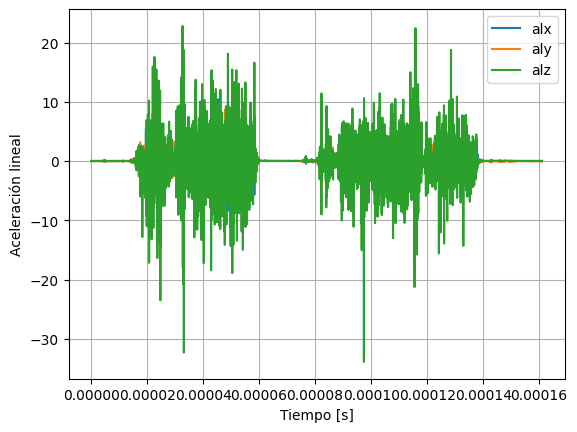

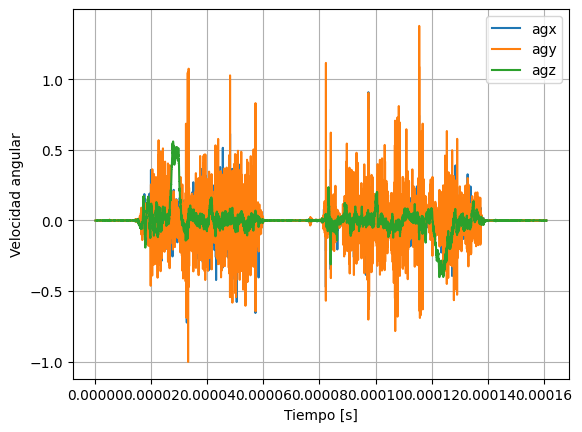

In [28]:
import matplotlib.pyplot as plt

df_init = df_merge[df_merge["timestamp"] <= 20.0]

plt.figure()
plt.plot(df_init["timestamp"], df_init["alx"], label="alx")
plt.plot(df_init["timestamp"], df_init["aly"], label="aly")
plt.plot(df_init["timestamp"], df_init["alz"], label="alz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración lineal")
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(df_init["timestamp"], df_init["agx"], label="agx")
plt.plot(df_init["timestamp"], df_init["agy"], label="agy")
plt.plot(df_init["timestamp"], df_init["agz"], label="agz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad angular")
plt.grid()
plt.legend()
plt.show()

In [29]:
gn = init_values["gn"]
g0 = init_values["g0"]
acc_bias = init_values["acc_bias"]
gyro_bias = init_values["gyro_bias"]
gyro_noise = init_values["gyro_noise"]
acc_noise = init_values["acc_noise"]
q0_mean = init_values["q0_mean"]
biases = {
    "alx": acc_bias[0],
    "aly": acc_bias[1],
    "alz": acc_bias[2],
    "agx": gyro_bias[0],
    "agy": gyro_bias[1],
    "agz": gyro_bias[2],
}

biases

{'alx': np.float64(0.06307090905620037),
 'aly': np.float64(-0.0020226571472205276),
 'alz': np.float64(-0.027626663255956023),
 'agx': np.float64(0.0008695168753817961),
 'agy': np.float64(0.0001299489156994503),
 'agz': np.float64(0.0001301136224801447)}

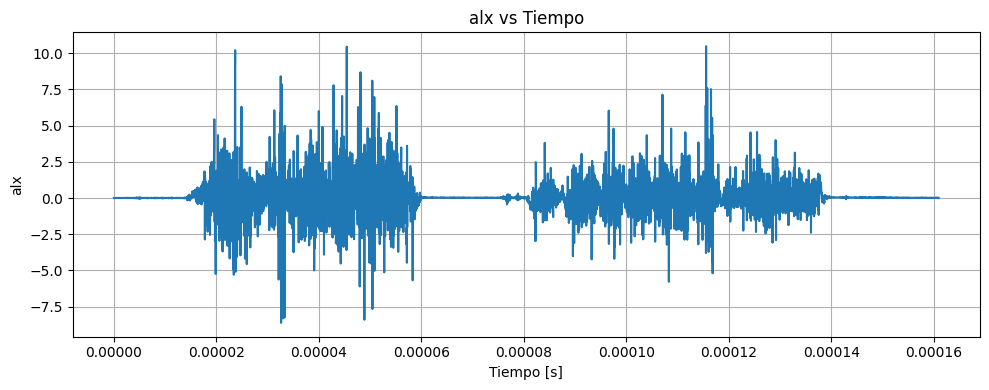

alx


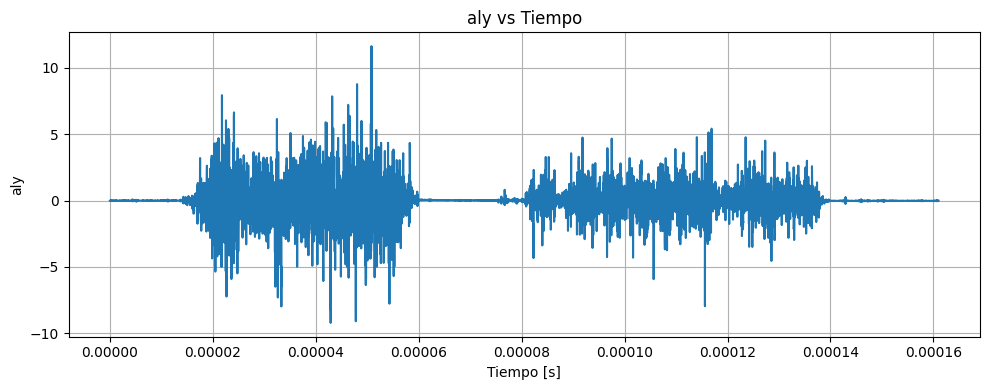

aly


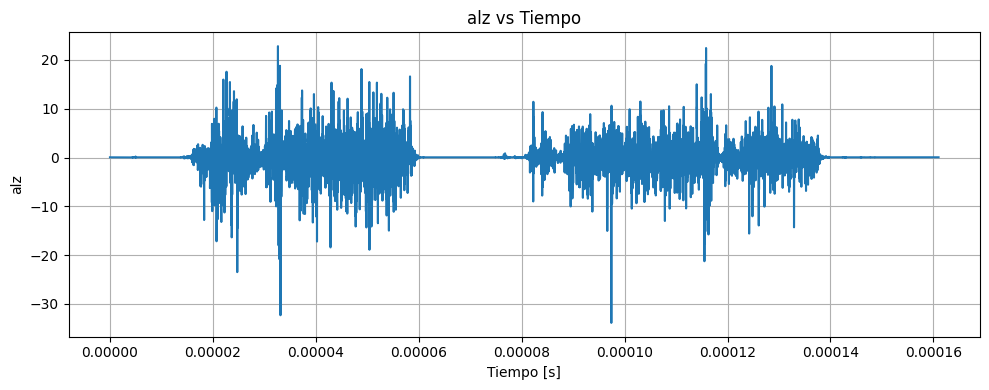

alz


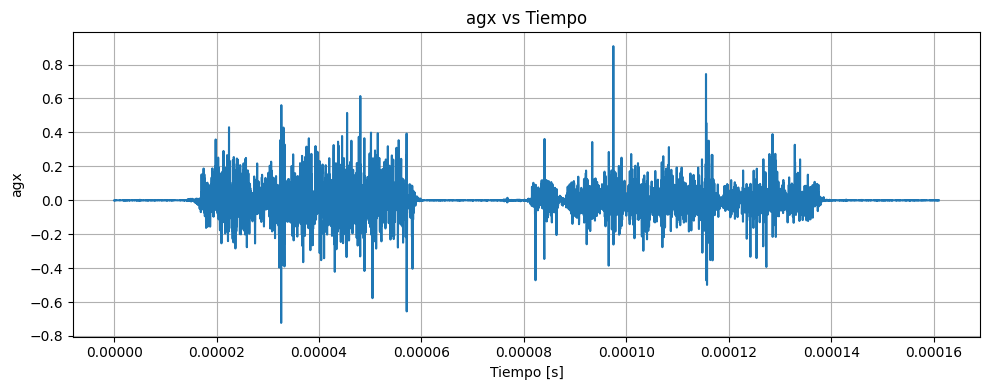

agx


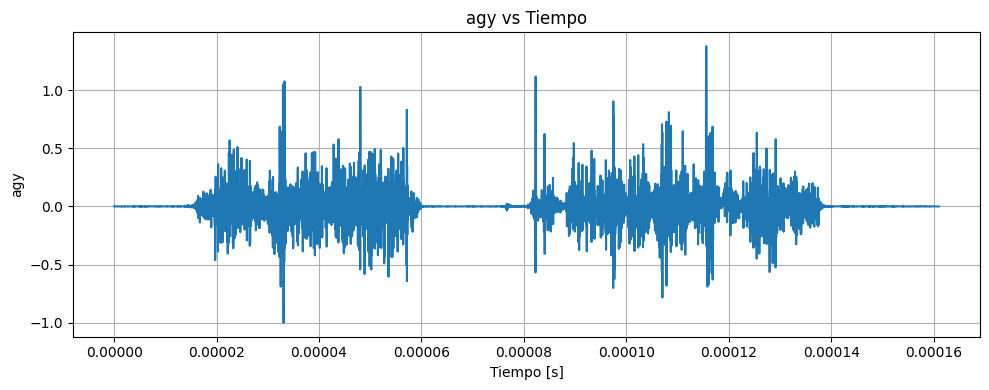

agy


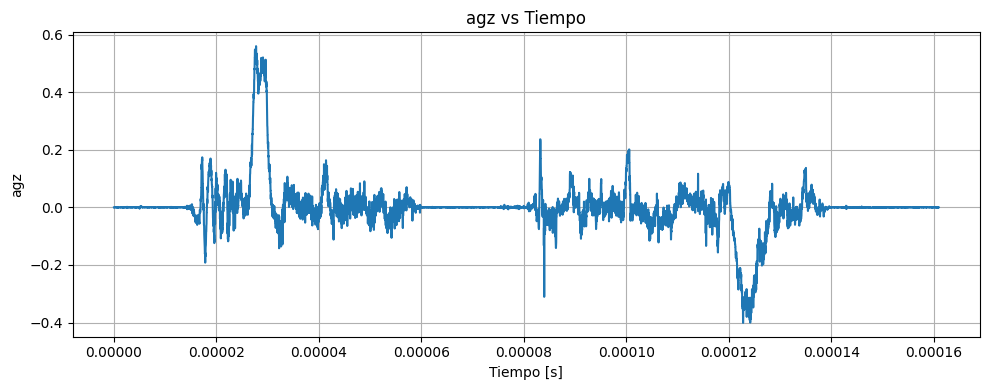

agz


In [30]:
# sigma = 0.01 # desviación estandar

# rudio_gyro = np.random.normal(loc=0, scale=sigma, size=n)

# # plt.plot(np.arange(n) * dt, rudio_gyro)
# plt.xlabel("Tiempo [s]")
# # plt.ylabel("Ruido del giroscopio [deg/s]")
# # plt.title("Ruido blanco en velocidad angular")
# # plt.grid()
# # plt.show()

# print(df.columns[3])
def plot_data_vs_time(df, col):
    df = df.copy()

    # Convertir Time a numérico
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    # Eliminar filas donde Time no pudo convertirse
    # df = df.dropna(subset=["Time"])

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # print(t)

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # print(df[col])

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col)
    plt.title(f"{col} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
        
# plot_data_vs_time(df=df, col="scaledAccelY")

for column in df_merge.columns[1:7]:
    plot_data_vs_time(df=df_merge, col=column)
    print(column)


In [31]:
df_merge.columns[:]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'flag', 'timestamp', 'dt', 'al_norm', 'ag_norm'],
      dtype='str')

In [32]:
# Etapa de filtrado

alx = df_merge['alx'].values
aly = df_merge['aly'].values
alz = df_merge['alz'].values
agx = df_merge['agx'].values
agy = df_merge['agy'].values
agz = df_merge['agz'].values

ang_acc = np.vstack((alx, aly, alz, agx, agy, agz)).T

ang_acc

array([[-1.5830e-03, -6.8300e-04,  4.0660e-02, -5.2900e-04,  6.6000e-05,
        -2.2300e-04],
       [ 2.8200e-04, -2.2290e-03,  4.0869e-02,  2.8900e-04,  3.1200e-04,
        -1.6100e-04],
       [-1.3880e-03,  5.0710e-03,  3.9841e-02, -3.8800e-04,  2.2800e-04,
         4.1000e-04],
       ...,
       [ 7.0080e-03, -3.0093e-02,  5.3230e-02, -7.3700e-04, -5.3200e-04,
         7.9200e-04],
       [ 4.3990e-03, -7.0000e-04,  4.7458e-02, -7.1300e-04, -1.9100e-04,
        -8.3000e-05],
       [ 4.3990e-03, -7.0000e-04,  4.7458e-02, -7.1300e-04, -1.9100e-04,
        -8.3000e-05]], shape=(13116, 6))

In [33]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fs = 100.0      # Hz
fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
agx_f = filtfilt(b, a, agx)
agy_f = filtfilt(b, a, agy)
agz_f = filtfilt(b, a, agz)
alx_f

array([-0.0015144 , -0.00170666, -0.0017988 , ...,  0.00901351,
        0.00643266,  0.00403838], shape=(13116,))

In [34]:
df_merge['alx_f'] = alx_f
df_merge['aly_f'] = aly_f
df_merge['alz_f'] = alz_f
df_merge['agx_f'] = agx_f
df_merge['agy_f'] = agy_f
df_merge['agz_f'] = agz_f
df_merge.columns[:]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'flag', 'timestamp', 'dt', 'al_norm', 'ag_norm', 'alx_f', 'aly_f',
       'alz_f', 'agx_f', 'agy_f', 'agz_f'],
      dtype='str')

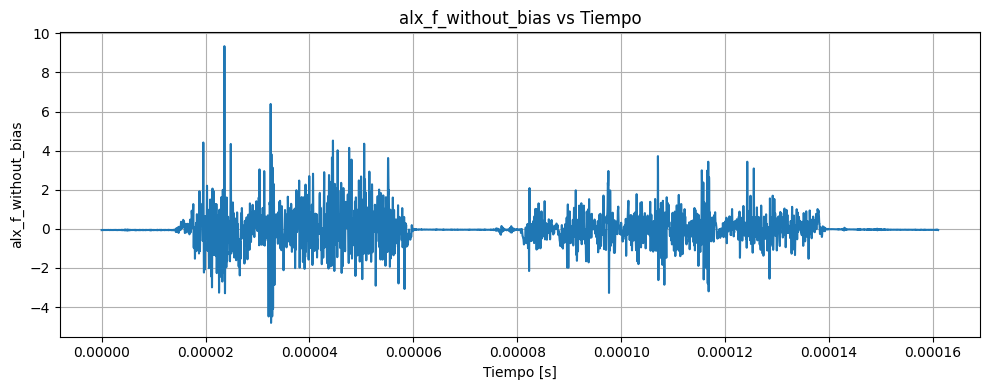

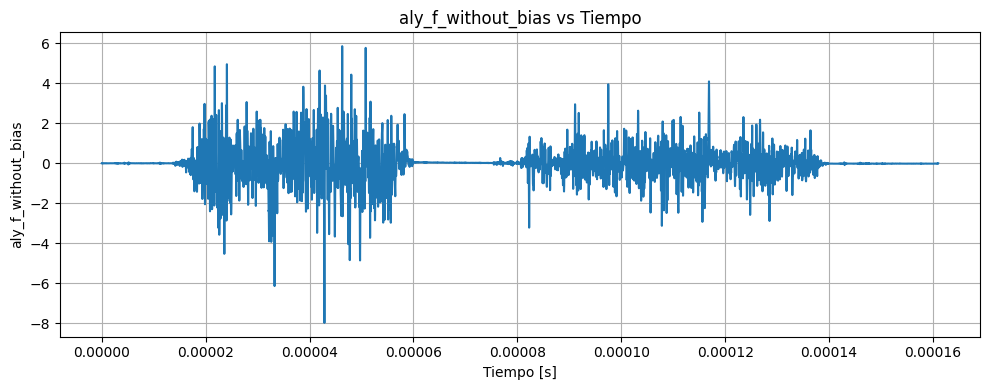

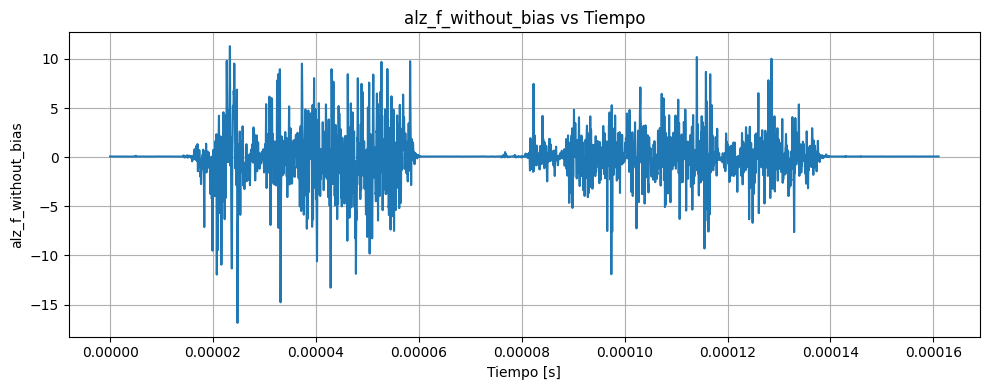

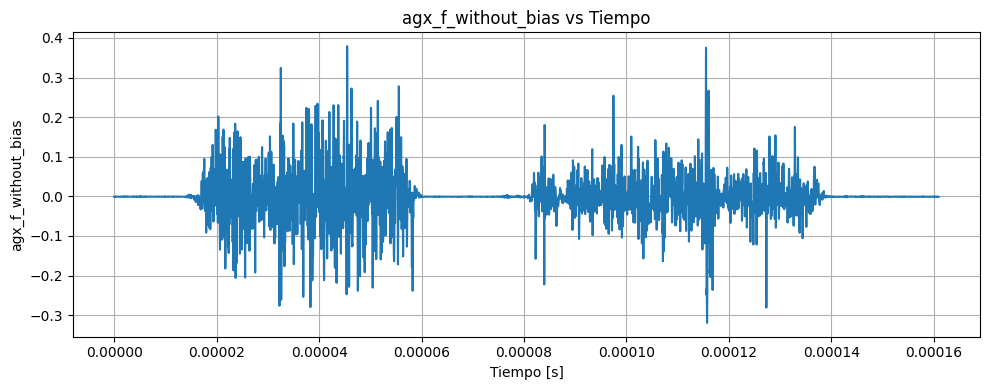

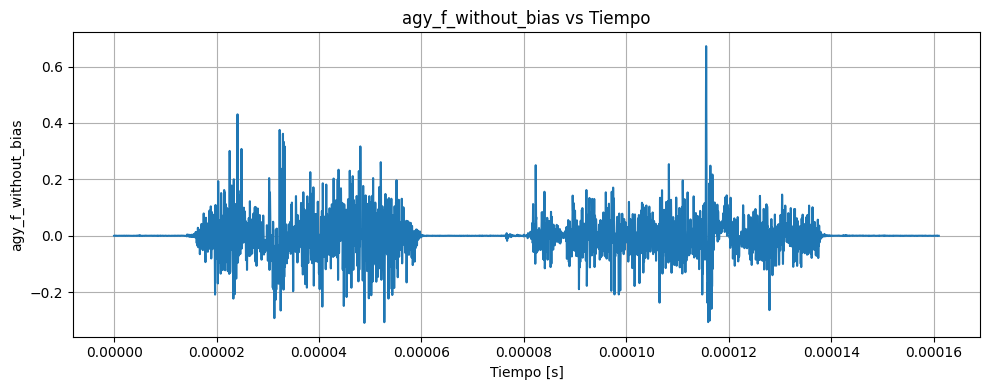

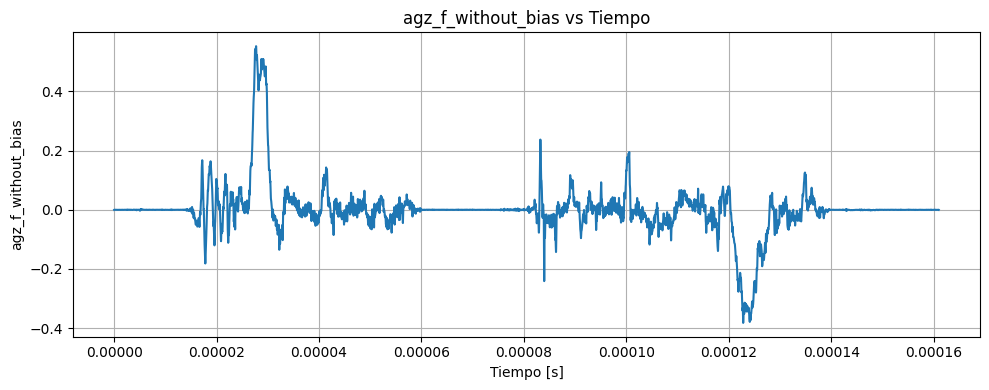

In [35]:
def data_without_bias(df, col_input, col_output):
    # print(df)
    # df[col_output] = df[col_input] - mean(df, col_input)
    # print(df[col_input])
    # print(biases[col_input])
    df[col_output] = df[col_input+"_f"] - biases[col_input]
    # print(biases)
    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col_output], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_output)
    plt.title(f"{col_output} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df_merge.columns[1:7]:
    data_without_bias(df=df_merge, col_input=column, col_output=column+"_f"+"_without_bias")
    # print(column+"_without_bias", " u:", biases[column], " o2:", var[column]," o:", std[column])

# print(df_merge.columns[13:19])

In [36]:
print(df_merge.columns[:])
df_merge["dt"]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'flag', 'timestamp', 'dt', 'al_norm', 'ag_norm', 'alx_f', 'aly_f',
       'alz_f', 'agx_f', 'agy_f', 'agz_f', 'alx_f_without_bias',
       'aly_f_without_bias', 'alz_f_without_bias', 'agx_f_without_bias',
       'agy_f_without_bias', 'agz_f_without_bias'],
      dtype='str')


0                 NaN
1        1.000000e-08
2        1.100000e-08
3        1.000000e-08
4        1.800000e-08
             ...     
13111    1.000000e-08
13112    1.800000e-08
13113    1.000000e-08
13114    1.200000e-08
13115    1.000000e-08
Name: dt, Length: 13116, dtype: float64

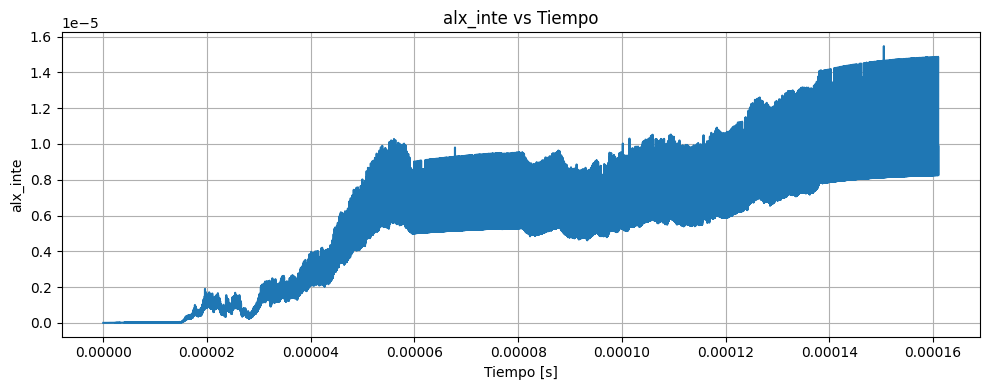

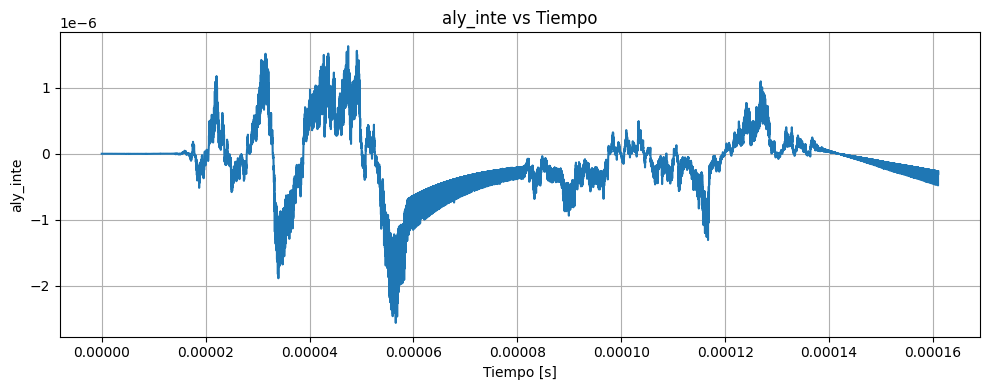

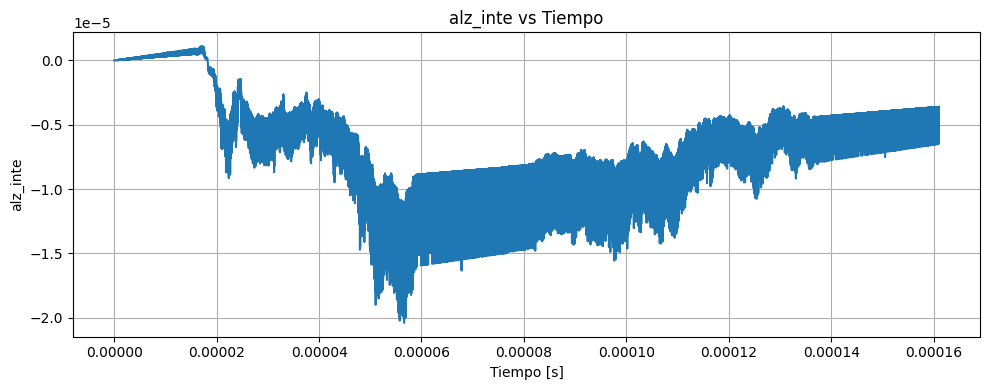

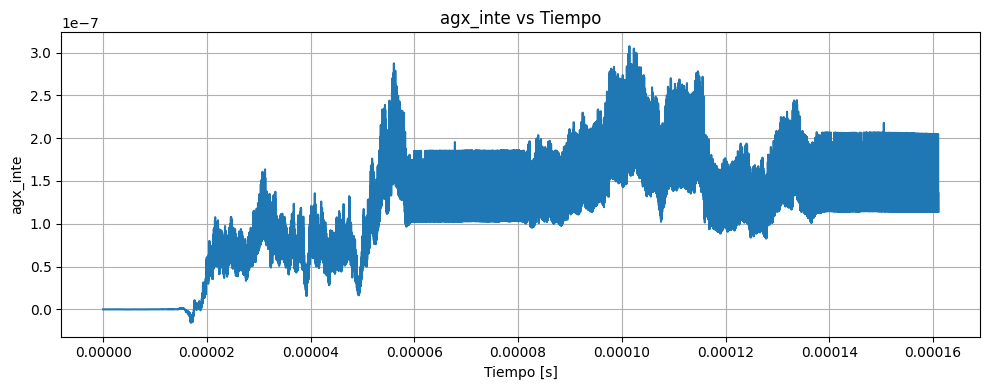

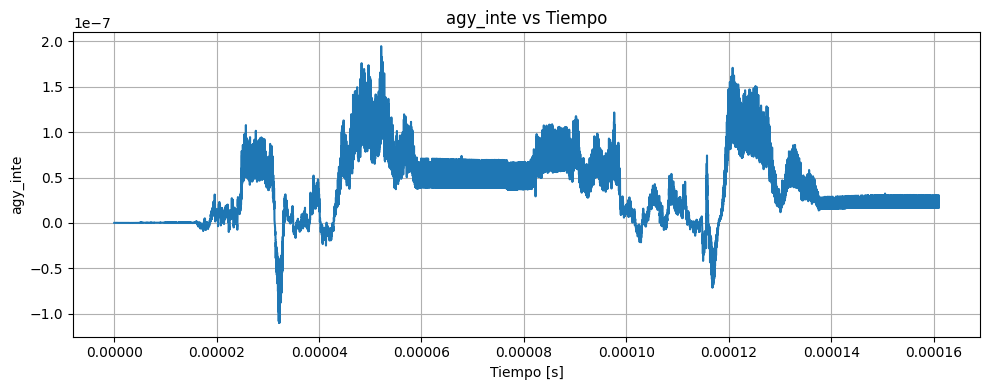

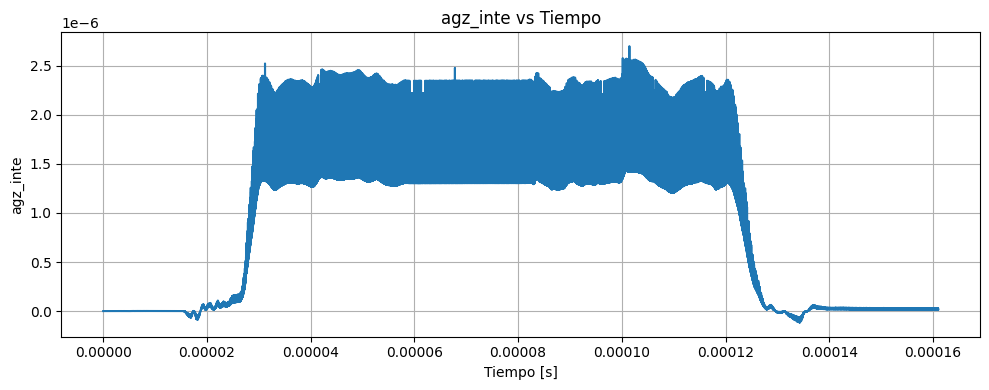

In [37]:
def plot_integ_data_vs_time(df, col_input):#, col_output):
    # df = df.copy()

    y = np.cumsum(df[col_input]) * df_merge["dt"]

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # y = df[col_output]

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_input+'_inte')
    plt.title(f"{col_input+'_inte'} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df_merge.columns[1:7]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)#col_output=column+"_inte")
    # print(column+"_inte", " u:", mean(df,column+"_inte"), " o2:", variance(df,column+"_inte")," o:", standard_deviation(df,column+"_inte"))
    # print(column+"_inte", " u:", mean(df, column), " o2:", variance(df, column)," o:", standard_deviation(df, column))

# for column in df.columns[1:]:
#     print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))

    

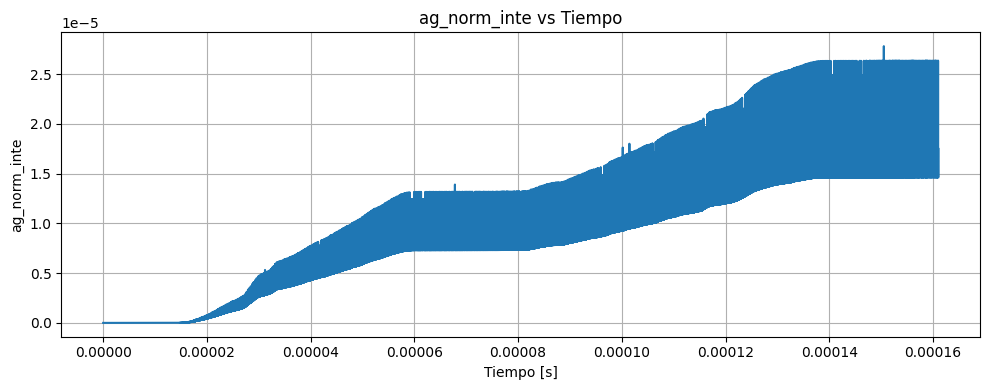

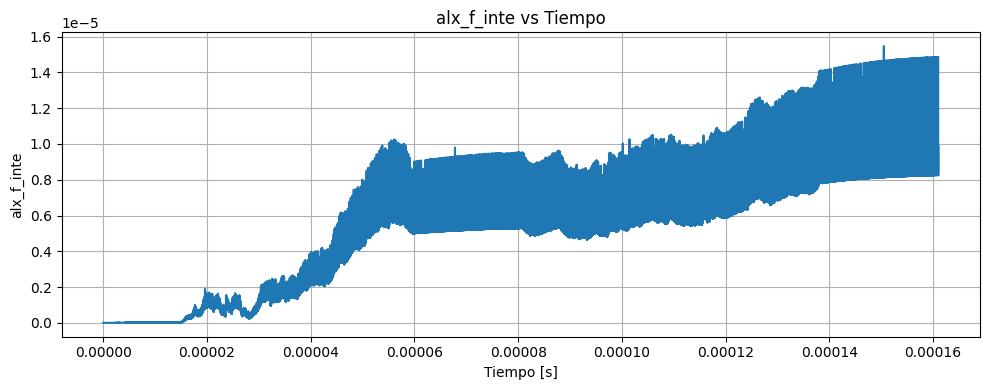

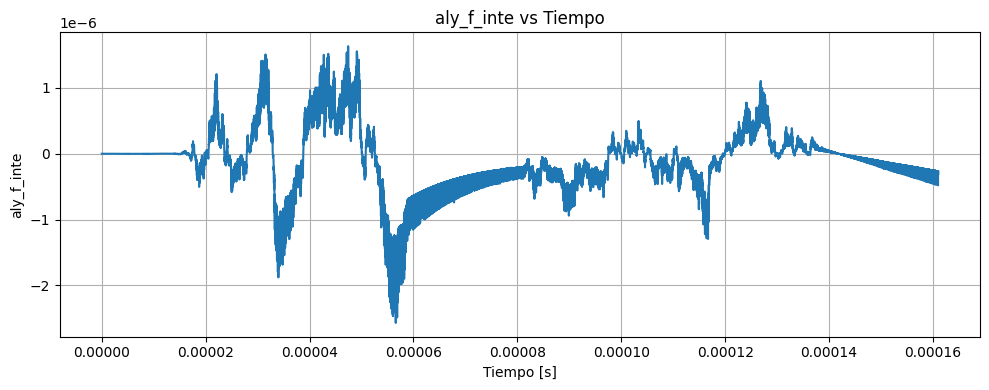

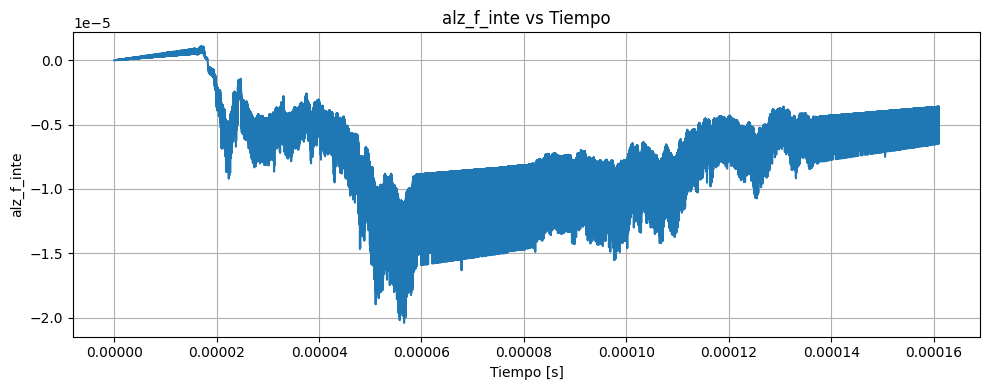

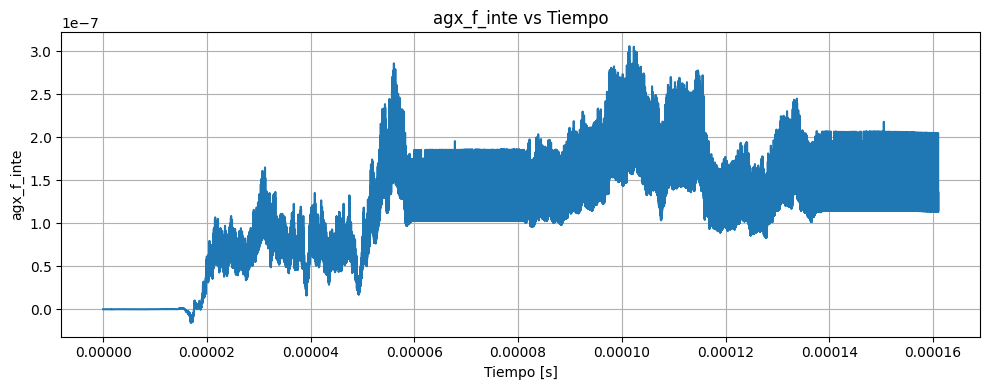

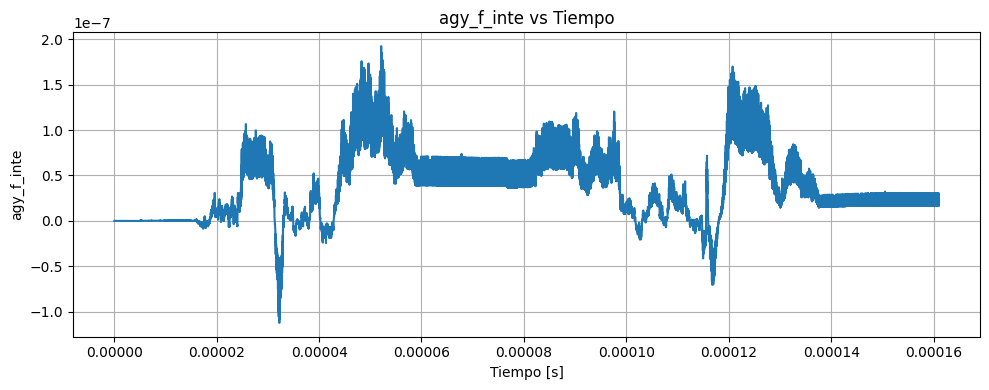

In [38]:
for column in df_merge.columns[15:21]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)

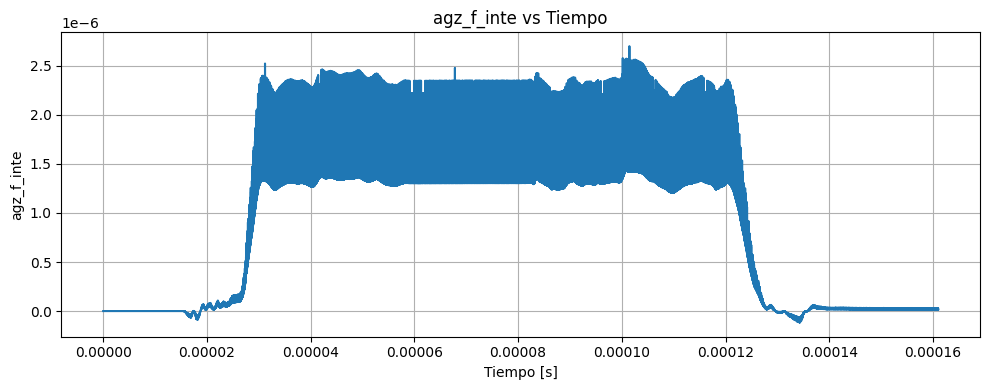

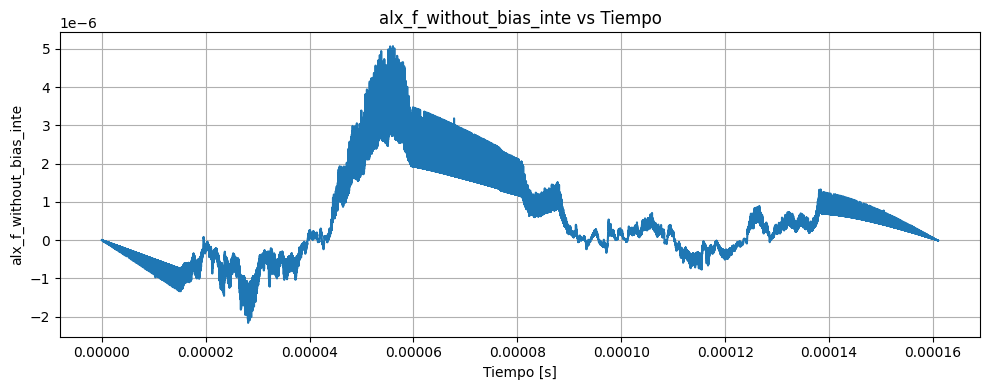

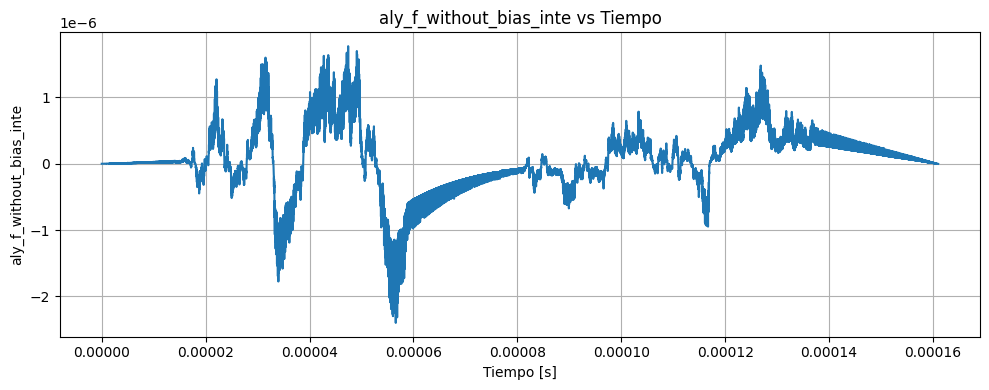

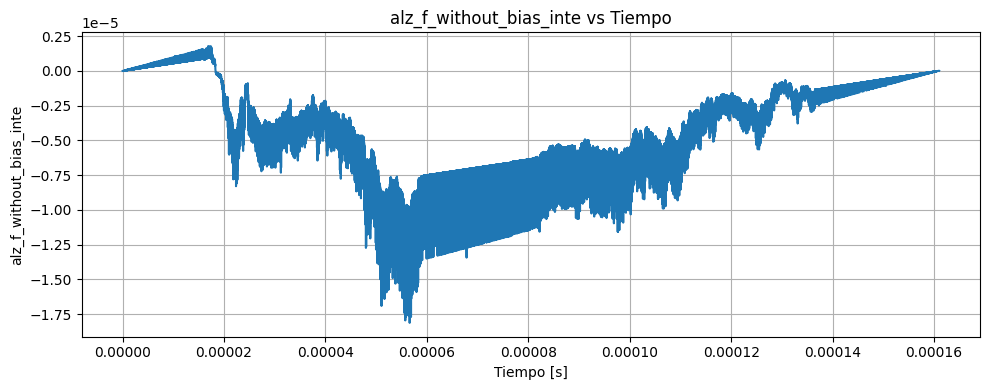

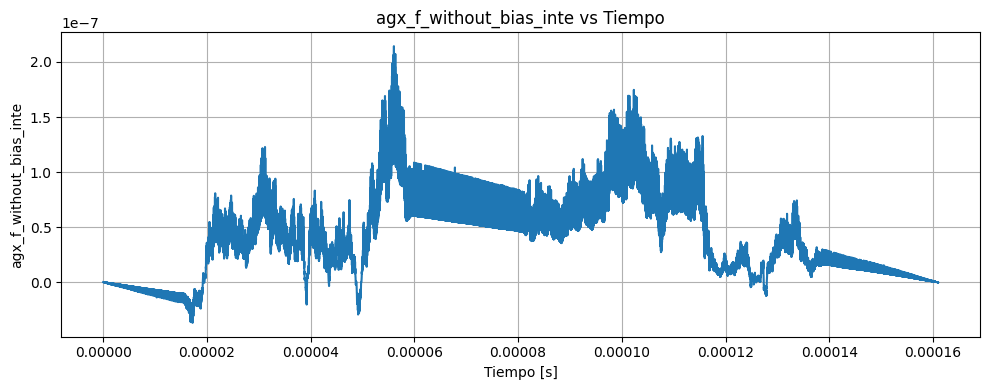

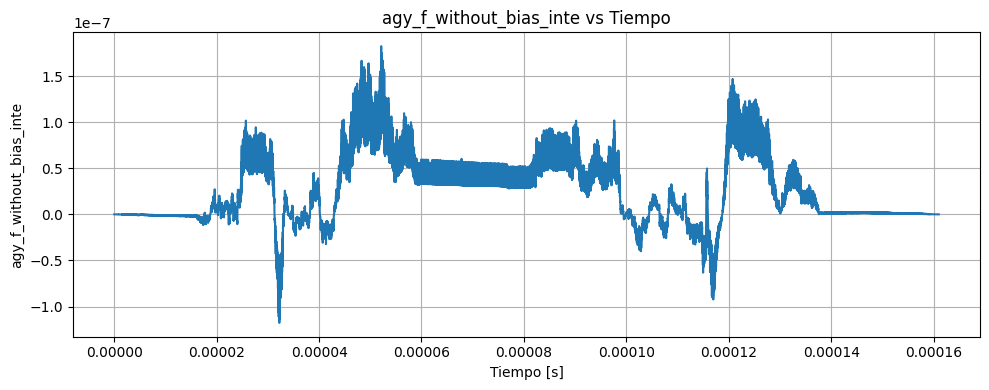

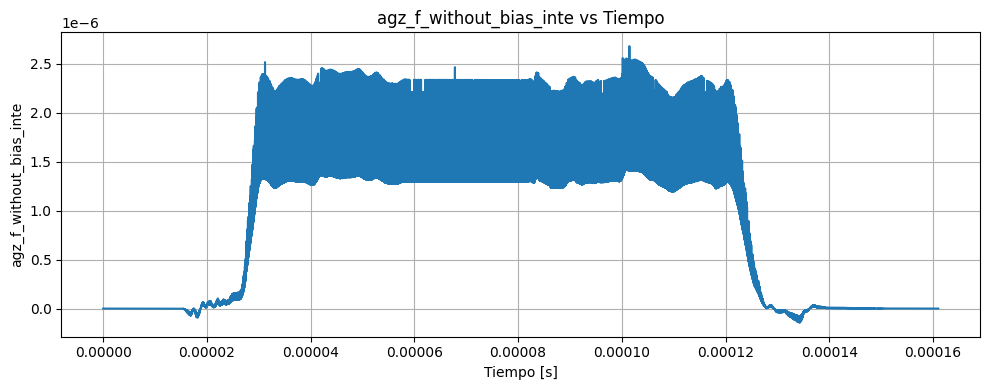

In [39]:
for column in df_merge.columns[21:28]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)

In [40]:
df_merge

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,alz_f,agx_f,agy_f,agz_f,alx_f_without_bias,aly_f_without_bias,alz_f_without_bias,agx_f_without_bias,agy_f_without_bias,agz_f_without_bias
0,1777931639370,-0.001583,-0.000683,0.040660,-0.000529,0.000066,-0.000223,0.999981,0.001548,0.005987,...,0.040583,-0.000527,0.000067,-0.000221,-0.064585,0.001347,0.068210,-0.001396,-0.000063,-0.000351
1,1777931639380,0.000282,-0.002229,0.040869,0.000289,0.000312,-0.000161,0.999981,0.001534,0.005982,...,0.039149,-0.000536,0.000250,-0.000053,-0.064778,-0.000291,0.066776,-0.001406,0.000120,-0.000184
2,1777931639391,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,...,0.037511,-0.000569,0.000388,0.000095,-0.064870,-0.001944,0.065138,-0.001438,0.000258,-0.000035
3,1777931639401,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,...,0.035584,-0.000632,0.000448,0.000212,-0.064712,-0.003385,0.063211,-0.001501,0.000318,0.000082
4,1777931639419,0.000961,-0.009677,0.032349,-0.000876,0.000885,0.000028,0.999982,0.001542,0.005748,...,0.033518,-0.000709,0.000416,0.000290,-0.064135,-0.004143,0.061145,-0.001578,0.000286,0.000160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13111,1777931800324,0.014305,-0.032856,0.039753,-0.001580,0.000508,-0.000197,0.999667,0.004573,0.006895,...,0.046347,-0.000854,0.000058,0.000082,-0.049218,-0.028598,0.073974,-0.001723,-0.000072,-0.000048
13112,1777931800342,0.007008,-0.030093,0.053230,-0.000737,-0.000532,0.000792,0.999667,0.004567,0.006892,...,0.046790,-0.000952,-0.000013,0.000181,-0.051447,-0.025794,0.074417,-0.001822,-0.000143,0.000050
13113,1777931800352,0.007008,-0.030093,0.053230,-0.000737,-0.000532,0.000792,0.999667,0.004567,0.006892,...,0.047127,-0.000950,-0.000081,0.000181,-0.054057,-0.019351,0.074753,-0.001819,-0.000211,0.000051
13114,1777931800364,0.004399,-0.000700,0.047458,-0.000713,-0.000191,-0.000083,0.999667,0.004565,0.006896,...,0.047288,-0.000860,-0.000137,0.000083,-0.056638,-0.009915,0.074915,-0.001729,-0.000267,-0.000048


In [41]:

def normalized(x):
    x = np.asarray(x, dtype=float)
    n = np.linalg.norm(x)
    if n < 1e-12:
        return x
    return x / n

def I(n):
    '''
    unit matrix
    just making its name prettier than np.eye
    '''
    return np.eye(n)

def skew(x):
    '''
    takes in a 3d column vector
    returns its Skew-symmetric matrix
    '''

    x = x.T[0]
    return np.array([[0, -x[2], x[1]], [x[2], 0, -x[0]], [-x[1], x[0], 0]])

def rotate(q):
    '''
    rotation transformation matrix
    nav frame to body frame as q is expected to be q^nb
    R(q) @ x to rotate x
    '''

    qv = q[1:4, :]
    qc = q[0]
    return (qc**2 - qv.T @ qv) * I(3) - 2 * qc * skew(qv) + 2 * qv @ qv.T


In [42]:
import numpy as np

def compute_navigation_acceleration(
    df,
    # init,
    accel_cols=("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias"),
    quat_cols=("q0", "q1", "q2", "q3")
):
    """
    Calcula aceleración en marco navegación usando aceleración lineal del IMU
    y cuaternión.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con aceleraciones y cuaterniones.

    init : dict
        Diccionario devuelto por initialize_from_dataframe(...).
        Debe contener init["gn"].

    accel_cols : tuple
        Columnas de aceleración en body/frame IMU.
        Ejemplo:
            ("alx", "aly", "alz")
            ("alx_f", "aly_f", "alz_f")
            ("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias")

    quat_cols : tuple
        Columnas de cuaternión.
        Por defecto: ("q0", "q1", "q2", "q3")

    Retorna
    -------
    df_out, orix, oriy, oriz
    """

    # gn = np.asarray(init["gn"], dtype=float).reshape(3, 1)

    required_cols = list(accel_cols) + list(quat_cols)
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    df_out = df.copy()

    a_nav = []
    orix = []
    oriy = []
    oriz = []

    init_ori = I(3)

    conj = -I(4)
    conj[0, 0] = 1

    for _, row in df_out.iterrows():

        at = np.array([
            [row[accel_cols[0]]],
            [row[accel_cols[1]]],
            [row[accel_cols[2]]]
        ], dtype=float)

        q = np.array([
            [row[quat_cols[0]]],
            [row[quat_cols[1]]],
            [row[quat_cols[2]]],
            [row[quat_cols[3]]]
        ], dtype=float)

        q = normalized(q)

        R_nb = rotate(conj @ q)

        an = R_nb @ at # + gn
        orin = R_nb @ init_ori

        a_nav.append(an.ravel())
        orix.append(orin[0, :])
        oriy.append(orin[1, :])
        oriz.append(orin[2, :])

    a_nav = np.array(a_nav)
    orix = np.array(orix)
    oriy = np.array(oriy)
    oriz = np.array(oriz)

    df_out["anx"] = a_nav[:, 0]
    df_out["any"] = a_nav[:, 1]
    df_out["anz"] = a_nav[:, 2]

    return df_out, orix, oriy, oriz

In [43]:
df_nav, orix, oriy, oriz = compute_navigation_acceleration(
    df_merge,
    accel_cols=("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias")
)

In [44]:
df_nav.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,agz_f,alx_f_without_bias,aly_f_without_bias,alz_f_without_bias,agx_f_without_bias,agy_f_without_bias,agz_f_without_bias,anx,any,anz
0,1777931639370,-0.001583,-0.000683,0.040660,-0.000529,0.000066,-0.000223,0.999981,0.001548,0.005987,...,-0.000221,-0.064585,0.001347,0.068210,-0.001396,-0.000063,-0.000351,-0.063764,0.001136,0.068982
1,1777931639380,0.000282,-0.002229,0.040869,0.000289,0.000312,-0.000161,0.999981,0.001534,0.005982,...,-0.000053,-0.064778,-0.000291,0.066776,-0.001406,0.000120,-0.000184,-0.063974,-0.000497,0.067545
2,1777931639391,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,...,0.000095,-0.064870,-0.001944,0.065138,-0.001438,0.000258,-0.000035,-0.064086,-0.002144,0.065903
3,1777931639401,-0.001388,0.005071,0.039841,-0.000388,0.000228,0.000410,0.999981,0.001532,0.005984,...,0.000212,-0.064712,-0.003385,0.063211,-0.001501,0.000318,0.000082,-0.063951,-0.003579,0.063970
4,1777931639419,0.000961,-0.009677,0.032349,-0.000876,0.000885,0.000028,0.999982,0.001542,0.005748,...,0.000290,-0.064135,-0.004143,0.061145,-0.001578,0.000286,0.000160,-0.063427,-0.004345,0.061865


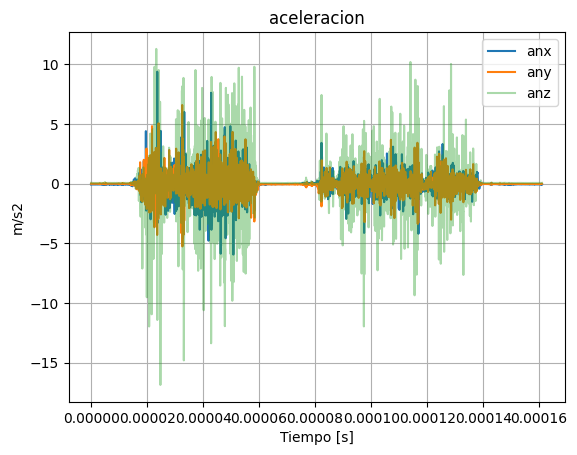

In [45]:
plt.figure()
plt.plot(df_nav["timestamp"], df_nav["anx"], label="anx")
plt.plot(df_nav["timestamp"], df_nav["any"], label="any")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(df_nav["timestamp"], df_nav["anz"], label="anz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion")
plt.show()

In [46]:
def zupt_df_from_flag_variable_dt(
    df,
    dt_col="dt",
    acc_cols=("anx", "any", "anz"),
    flag_col="flagStop",
    vel_cols=("vnx", "vny", "vnz"),
):
    """
    Aplica ZUPT usando flagStop y dt variable por muestra.

    Requiere columnas:
        anx, any, anz
        dt
        flagStop

    Donde:
        flagStop = 0 -> avance
        flagStop = 1 -> parado
    """

    df = df.copy()
    print(df.head())
    required_cols = list(acc_cols) + [dt_col, flag_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    for c in acc_cols + (dt_col,):
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df[flag_col] = pd.to_numeric(df[flag_col], errors="coerce").fillna(0).astype(int)

    df = df.dropna(subset=list(acc_cols) + [dt_col]).reset_index(drop=True)

    a_nav = df[list(acc_cols)].to_numpy(dtype=float)
    dt_array = df[dt_col].to_numpy(dtype=float)
    flag_stop = df[flag_col].to_numpy(dtype=int)

    sample_number = len(df)

    velocities = []
    zupt_flags = []

    prevt = -1
    still_phase = False

    v = np.zeros((3, 1))

    for t in range(sample_number):

        at = a_nav[t].reshape(3, 1)
        dt = dt_array[t]

        if flag_stop[t] == 1:

            zupt_flags.append(1)

            if not still_phase:

                predict_v = v + at * dt

                denom = t - prevt

                if denom > 0:
                    v_drift_rate = predict_v / denom

                    for i in range(t - prevt - 1):
                        idx = prevt + 1 + i
                        velocities[idx] -= (i + 1) * v_drift_rate.T[0]

            v = np.zeros((3, 1))
            prevt = t
            still_phase = True

        else:
            zupt_flags.append(0)

            v = v + at * dt
            still_phase = False

        velocities.append(v.T[0])

    velocities = np.array(velocities)

    df[vel_cols[0]] = velocities[:, 0]
    df[vel_cols[1]] = velocities[:, 1]
    df[vel_cols[2]] = velocities[:, 2]

    df["zupt_flag"] = zupt_flags

    return df

In [47]:
# import numpy as np

# def zupt_df(df, dt=0.005, threshold=0.02):
#     """
#     Aplica ZUPT usando aceleración en navegación desde un DataFrame.

#     Requiere columnas:
#         anx, any, anz

#     Agrega columnas:
#         vnx, vny, vnz
#         zupt_flag
#     """

#     df = df.copy()

#     # Pasar aceleración navegación a array Nx3
#     a_nav = df[["anx", "any", "anz"]].to_numpy(dtype=float)

#     sample_number = a_nav.shape[0]

#     velocities = []
#     zupt_flags = []

#     prevt = -1
#     still_phase = False

#     v = np.zeros((3, 1))

#     for t in range(sample_number):

#         at = a_nav[t].reshape(3, 1)

#         if np.linalg.norm(at) < threshold:
#             zupt_flags.append(1)

#             if not still_phase:
#                 predict_v = v + at * dt

#                 denom = t - prevt

#                 if denom > 0:
#                     v_drift_rate = predict_v / denom

#                     for i in range(t - prevt - 1):
#                         velocities[prevt + 1 + i] -= (i + 1) * v_drift_rate.T[0]

#             v = np.zeros((3, 1))
#             prevt = t
#             still_phase = True

#         else:
#             zupt_flags.append(0)

#             v = v + at * dt
#             still_phase = False

#         velocities.append(v.T[0])

#     velocities = np.array(velocities)

#     df["vnx"] = velocities[:, 0]
#     df["vny"] = velocities[:, 1]
#     df["vnz"] = velocities[:, 2]

#     df["zupt_flag"] = zupt_flags

#     return df

In [48]:
# df_zupt = zupt_df_from_flag(
#     df_nav,
#     dt=0.01,
#     threshold=0.02
# )
# df_zupt = zupt_df_from_flag(
#     df_merge,
#     dt=0.01,
#     acc_cols=("anx", "any", "anz"),
#     flag_col="flagStop"
# )
df_zupt = zupt_df_from_flag_variable_dt(
    df_nav,
    dt_col="dt",
    acc_cols=("anx", "any", "anz"),
    flag_col="flagStop"
)

            Time       alx       aly       alz       agx       agy       agz  \
0  1777931639370 -0.001583 -0.000683  0.040660 -0.000529  0.000066 -0.000223   
1  1777931639380  0.000282 -0.002229  0.040869  0.000289  0.000312 -0.000161   
2  1777931639391 -0.001388  0.005071  0.039841 -0.000388  0.000228  0.000410   
3  1777931639401 -0.001388  0.005071  0.039841 -0.000388  0.000228  0.000410   
4  1777931639419  0.000961 -0.009677  0.032349 -0.000876  0.000885  0.000028   

         q0        q1        q2  ...     agz_f  alx_f_without_bias  \
0  0.999981  0.001548  0.005987  ... -0.000221           -0.064585   
1  0.999981  0.001534  0.005982  ... -0.000053           -0.064778   
2  0.999981  0.001532  0.005984  ...  0.000095           -0.064870   
3  0.999981  0.001532  0.005984  ...  0.000212           -0.064712   
4  0.999982  0.001542  0.005748  ...  0.000290           -0.064135   

   aly_f_without_bias  alz_f_without_bias  agx_f_without_bias  \
0            0.001347            

ValueError: Faltan columnas en el DataFrame: ['flagStop']

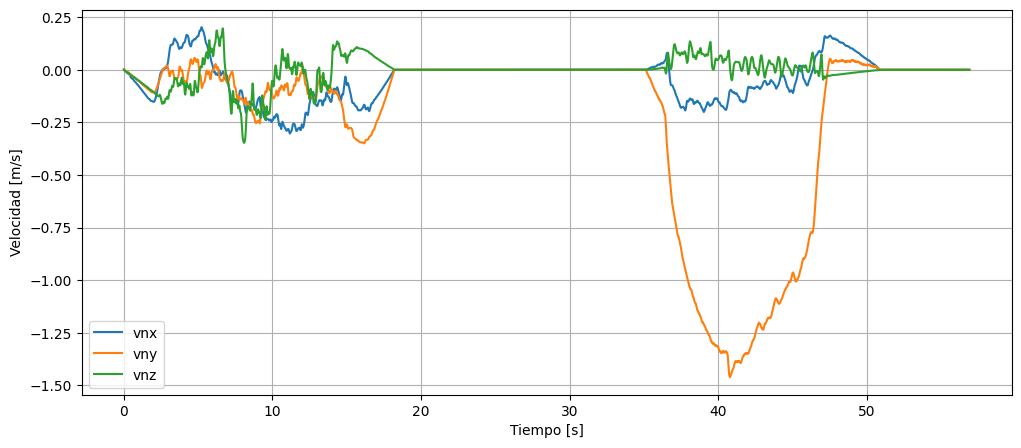

In [ ]:
import matplotlib.pyplot as plt

t = df_zupt["timestamp"] if "timestamp" in df_zupt.columns else np.arange(len(df_zupt))

plt.figure(figsize=(12, 5))
plt.plot(t, df_zupt["vnx"], label="vnx")
plt.plot(t, df_zupt["vny"], label="vny")
plt.plot(t, df_zupt["vnz"], label="vnz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.grid()
plt.legend()
plt.show()

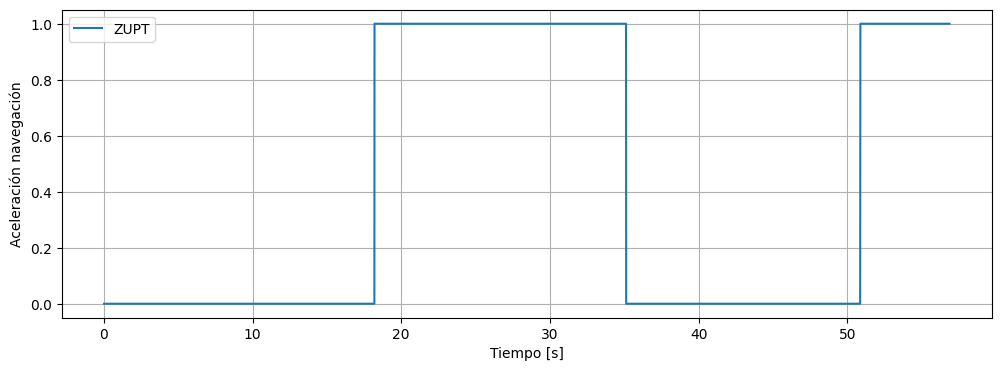

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, df_zupt["zupt_flag"], label="ZUPT")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración navegación")
plt.grid()
plt.legend()
plt.show()

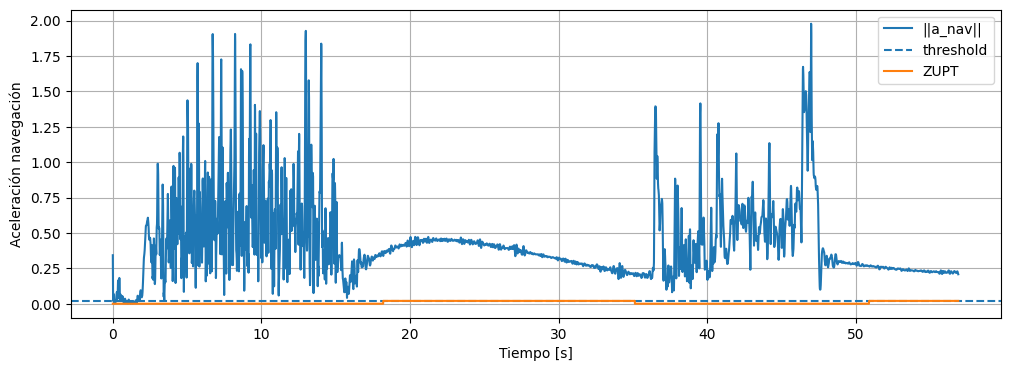

In [ ]:
a_norm = np.linalg.norm(df_zupt[["anx", "any", "anz"]].to_numpy(), axis=1)

plt.figure(figsize=(12, 4))
plt.plot(t, a_norm, label="||a_nav||")
plt.axhline(0.02, linestyle="--", label="threshold")
plt.plot(t, df_zupt["zupt_flag"] * 0.02, label="ZUPT")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración navegación")
plt.grid()
plt.legend()
plt.show()

In [ ]:
import numpy as np

def position_df(df, dt=0.01, use_dt_col=True):
    """
    Integra posición usando velocidad ZUPT.

    Requiere:
        vnx, vny, vnz

    Opcional:
        dt

    Agrega:
        px, py, pz, pnorm
    """

    df = df.copy()

    velocities = df[["vnx", "vny", "vnz"]].to_numpy(dtype=float)

    positions = []
    p = np.zeros((3, 1))

    for t in range(len(df)):

        vt = velocities[t].reshape(3, 1)

        if use_dt_col and "dt" in df.columns:
            dtk = float(df["dt"].iloc[t])

            if not np.isfinite(dtk) or dtk <= 0:
                dtk = dt
        else:
            dtk = dt

        p = p + vt * dtk

        positions.append(p.T[0])

    positions = np.array(positions)

    df["px"] = positions[:, 0]
    df["py"] = positions[:, 1]
    df["pz"] = positions[:, 2]

    df["pnorm"] = np.linalg.norm(positions, axis=1)

    return df

In [ ]:
df_pos = position_df(df_zupt, dt=0.01)

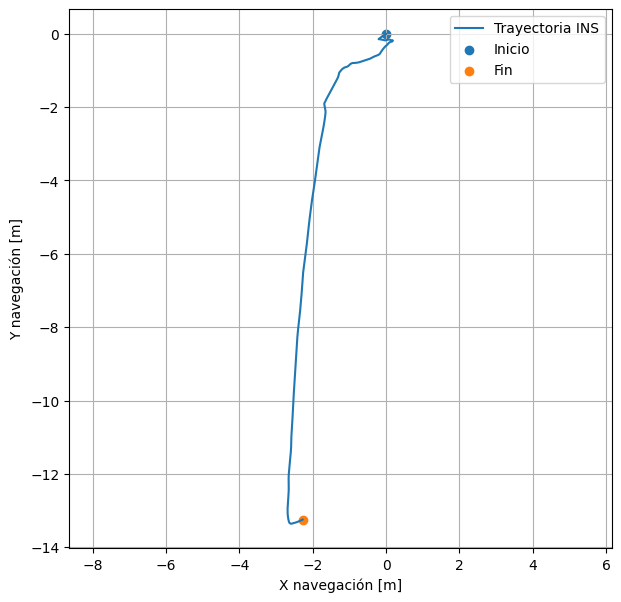

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_pos["px"], df_pos["py"], label="Trayectoria INS")
plt.scatter(df_pos["px"].iloc[0], df_pos["py"].iloc[0], label="Inicio")
plt.scatter(df_pos["px"].iloc[-1], df_pos["py"].iloc[-1], label="Fin")
plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [ ]:
import numpy as np

def nhc_df(df, K_nhc_y=1.0, K_nhc_z=1.0):
    """
    Aplica Non-Holonomic Constraint a la velocidad.

    Requiere columnas:
        vnx, vny, vnz
        q0, q1, q2, q3

    Agrega columnas:
        vbx_raw, vby_raw, vbz_raw
        vbx_nhc, vby_nhc, vbz_nhc
        vnx_nhc, vny_nhc, vnz_nhc
    """

    df = df.copy()

    required_cols = ["vnx", "vny", "vnz", "q0", "q1", "q2", "q3"]
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    conj = -I(4)
    conj[0, 0] = 1

    v_body_raw_list = []
    v_body_nhc_list = []
    v_nav_nhc_list = []

    for _, row in df.iterrows():

        # Velocidad en navegación
        v_nav = np.array([
            [row["vnx"]],
            [row["vny"]],
            [row["vnz"]]
        ], dtype=float)

        # Cuaternión q = [q0, q1, q2, q3]
        q = np.array([
            [row["q0"]],
            [row["q1"]],
            [row["q2"]],
            [row["q3"]]
        ], dtype=float)

        q = normalized(q)

        # Según tu convención:
        # rotate(conj @ q) = body -> nav
        # rotate(q)        = nav -> body
        v_body = rotate(q) @ v_nav

        vx_b = v_body[0, 0]
        vy_b = v_body[1, 0]
        vz_b = v_body[2, 0]

        # Aplicar NHC:
        # El vehículo no debería tener velocidad lateral ni vertical en body.
        vy_b_corr = vy_b * (1.0 - K_nhc_y)
        vz_b_corr = vz_b * (1.0 - K_nhc_z)

        v_body_corr = np.array([
            [vx_b],
            [vy_b_corr],
            [vz_b_corr]
        ], dtype=float)

        # Volver de body -> navegación
        v_nav_corr = rotate(conj @ q) @ v_body_corr

        v_body_raw_list.append(v_body.T[0])
        v_body_nhc_list.append(v_body_corr.T[0])
        v_nav_nhc_list.append(v_nav_corr.T[0])

    v_body_raw = np.array(v_body_raw_list)
    v_body_nhc = np.array(v_body_nhc_list)
    v_nav_nhc = np.array(v_nav_nhc_list)

    df["vbx_raw"] = v_body_raw[:, 0]
    df["vby_raw"] = v_body_raw[:, 1]
    df["vbz_raw"] = v_body_raw[:, 2]

    df["vbx_nhc"] = v_body_nhc[:, 0]
    df["vby_nhc"] = v_body_nhc[:, 1]
    df["vbz_nhc"] = v_body_nhc[:, 2]

    df["vnx_nhc"] = v_nav_nhc[:, 0]
    df["vny_nhc"] = v_nav_nhc[:, 1]
    df["vnz_nhc"] = v_nav_nhc[:, 2]

    return df

In [ ]:
df_nhc = nhc_df(
    df_zupt,
    K_nhc_y=1.0,
    K_nhc_z=1.0
)

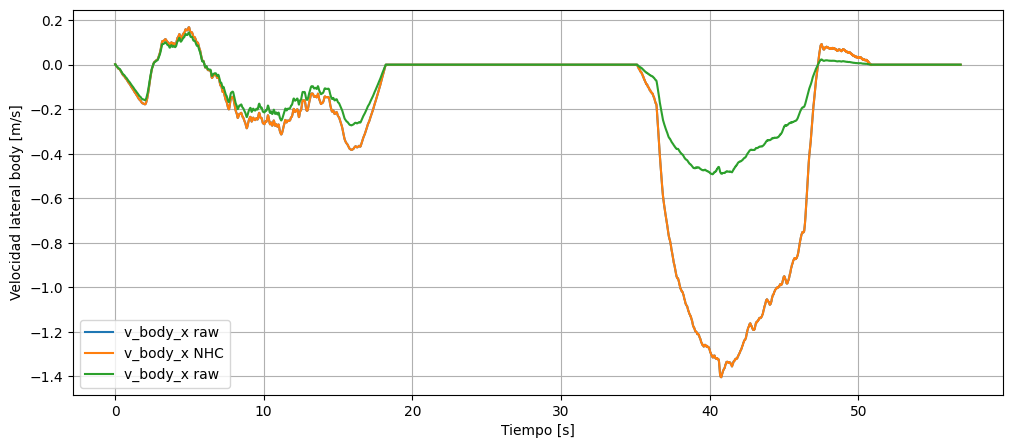

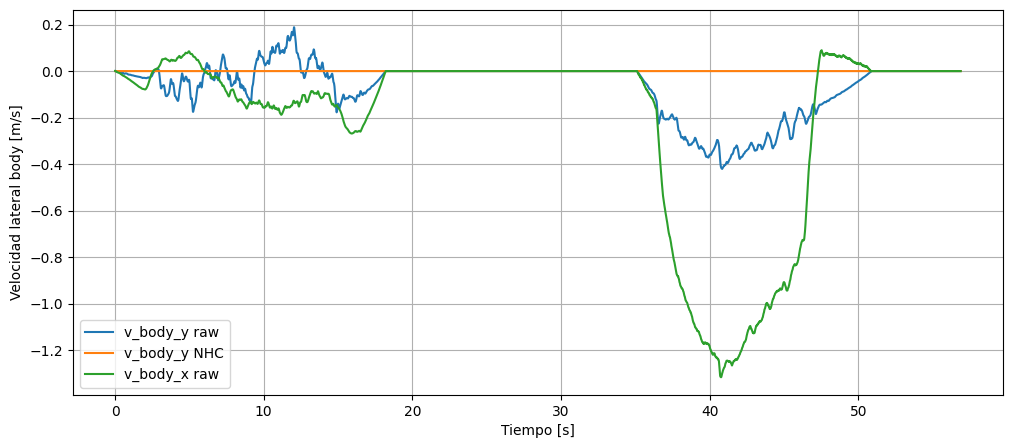

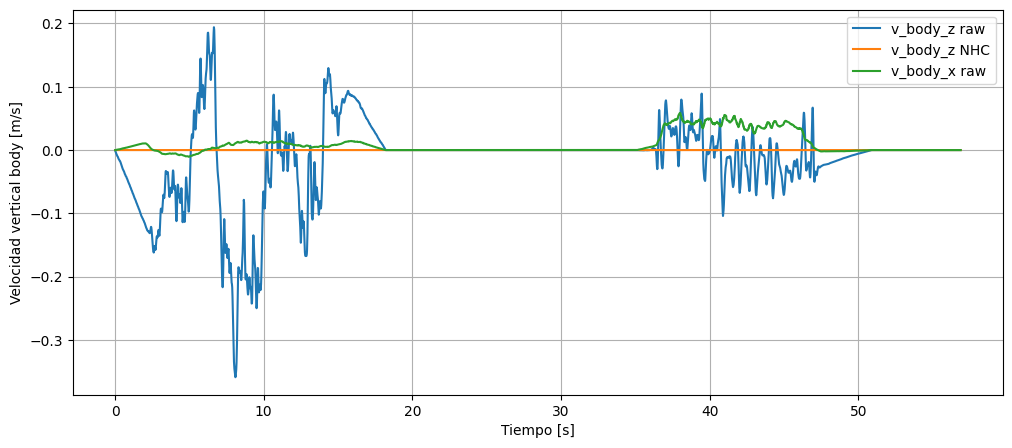

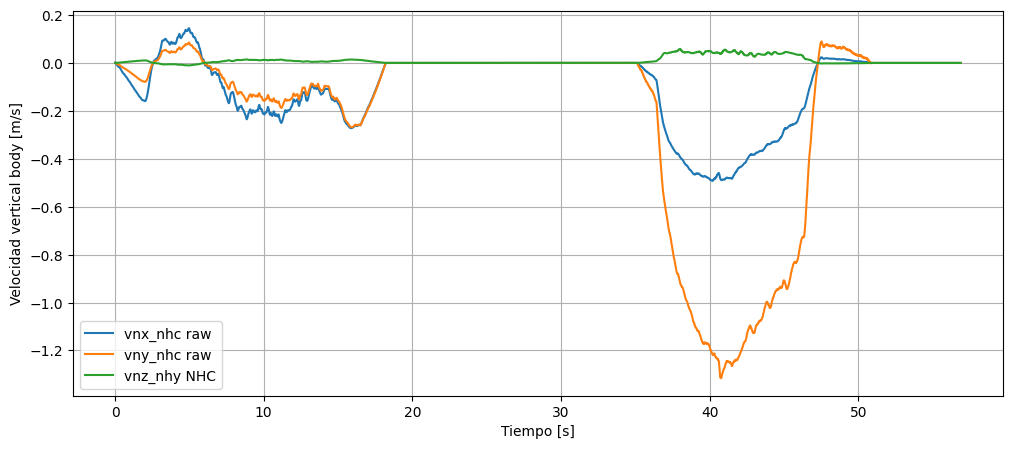

In [ ]:
import matplotlib.pyplot as plt

t = df_nhc["timestamp"] if "timestamp" in df_nhc.columns else np.arange(len(df_nhc))

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vbx_raw"], label="v_body_x raw")
plt.plot(t, df_nhc["vbx_nhc"], label="v_body_x NHC")
plt.plot(t, df_nhc["vnx_nhc"], label="v_body_x raw")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad lateral body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vby_raw"], label="v_body_y raw")
plt.plot(t, df_nhc["vby_nhc"], label="v_body_y NHC")
plt.plot(t, df_nhc["vny_nhc"], label="v_body_x raw")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad lateral body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vbz_raw"], label="v_body_z raw")
plt.plot(t, df_nhc["vbz_nhc"], label="v_body_z NHC")
plt.plot(t, df_nhc["vnz_nhc"], label="v_body_x raw")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad vertical body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vnx_nhc"], label="vnx_nhc raw")
plt.plot(t, df_nhc["vny_nhc"], label="vny_nhc raw")
plt.plot(t, df_nhc["vnz_nhc"], label="vnz_nhy NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad vertical body [m/s]")
plt.grid()
plt.legend()
plt.show()

In [ ]:
def add_position_from_nhc_to_df(df, dt=None, use_corrected_acc=True, use_acc_term=True):
    """
    Integra posición en frame navegación usando velocidades corregidas por NHC.

    Parámetros
    ----------
    df : pandas.DataFrame
        Debe contener:
        - vx_nhc, vy_nhc, vz_nhc
        - y además anx_corr, any_corr, anz_corr
          o anx, any, anz
    dt : float o None
        Si es None, usa el promedio de la columna 'dt'.
    use_corrected_acc : bool
        Si True, usa anx_corr/any_corr/anz_corr si existen.
        Si no, usa anx/any/anz.
    use_acc_term : bool
        Si True, usa:
            p = p + v*dt + 0.5*a*dt^2
        Si False, usa:
            p = p + v*dt

    Retorna
    -------
    df_out : pandas.DataFrame
        DataFrame con columnas agregadas:
        - px_nhc
        - py_nhc
        - pz_nhc
        - pnorm_nhc
    """

    df_out = df.copy()

    # -------------------------
    # 1) verificar velocidades NHC
    # -------------------------
    vel_cols = ["vnx_nhc", "vny_nhc", "vnz_nhc"]
    missing_vel = [c for c in vel_cols if c not in df_out.columns]
    if missing_vel:
        raise ValueError(f"Faltan columnas de velocidad NHC: {missing_vel}")

    # -------------------------
    # 2) seleccionar aceleración navegación
    # -------------------------
    if use_corrected_acc and all(c in df_out.columns for c in ["anx_corr", "any_corr", "anz_corr"]):
        acc_cols = ["anx_corr", "any_corr", "anz_corr"]
    elif all(c in df_out.columns for c in ["anx", "any", "anz"]):
        acc_cols = ["anx", "any", "anz"]
    else:
        raise ValueError(
            "No se encontraron columnas de aceleración navegación. "
            "Se esperaban anx/any/anz o anx_corr/any_corr/anz_corr."
        )

    # -------------------------
    # 3) obtener dt
    # -------------------------
    if dt is None:
        if "dt" not in df_out.columns:
            raise ValueError("Debes pasar dt o incluir columna 'dt' en el DataFrame.")

        dt_values = pd.to_numeric(df_out["dt"], errors="coerce").to_numpy(dtype=float)
        dt_values = dt_values[np.isfinite(dt_values) & (dt_values > 0)]

        if len(dt_values) == 0:
            raise ValueError("No hay valores válidos de dt en el DataFrame.")

        dt = np.mean(dt_values)

    # -------------------------
    # 4) extraer datos
    # -------------------------
    a_nav = df_out[acc_cols].to_numpy(dtype=float)
    v_nhc = df_out[vel_cols].to_numpy(dtype=float)

    sample_number = a_nav.shape[0]

    # -------------------------
    # 5) integración
    # -------------------------
    positions = []
    p = np.array([[0.0], [0.0], [0.0]])

    t = 0
    while t < sample_number:
        at = a_nav[t, np.newaxis].T
        vt = v_nhc[t, np.newaxis].T

        if use_acc_term:
            p = p + vt * dt # +  0.5 * at * dt**2
        else:
            p = p + vt * dt

        positions.append(p.T[0])
        t += 1

    positions = np.array(positions)

    # -------------------------
    # 6) guardar columnas
    # -------------------------
    df_out["px_nhc"] = positions[:, 0]
    df_out["py_nhc"] = positions[:, 1]
    df_out["pz_nhc"] = positions[:, 2]
    df_out["pnorm_nhc"] = np.linalg.norm(positions, axis=1)

    return df_out

In [ ]:
data = add_position_from_nhc_to_df(
    df_nhc,
    dt=0.01,
    use_corrected_acc=True,
    use_acc_term=True
)

data.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,vbx_nhc,vby_nhc,vbz_nhc,vnx_nhc,vny_nhc,vnz_nhc,px_nhc,py_nhc,pz_nhc,pnorm_nhc
0,1777415753016559684,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,...,0.002326,0.0,-0.0,0.002117,0.000953,-0.000133,0.000021,0.000010,-0.000001,0.000023
1,1777415753026651662,-0.545940,-0.106244,0.026371,-0.001580,0.001981,0.018396,0.977315,-0.005265,0.028184,...,0.002755,0.0,-0.0,0.002508,0.001129,-0.000158,0.000046,0.000021,-0.000003,0.000051
2,1777415753036301759,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,...,0.001854,0.0,-0.0,0.001687,0.000760,-0.000106,0.000063,0.000028,-0.000004,0.000069
3,1777415753046387868,-0.555377,-0.059631,0.015700,-0.001255,0.002622,0.018263,0.977277,-0.005277,0.028206,...,0.000246,-0.0,-0.0,0.000224,0.000101,-0.000014,0.000065,0.000029,-0.000004,0.000072
4,1777415753056052835,-0.558302,-0.064261,0.020169,-0.000963,0.003266,0.019145,0.977235,-0.005289,0.028242,...,-0.001527,-0.0,-0.0,-0.001389,-0.000627,0.000088,0.000051,0.000023,-0.000003,0.000057


In [ ]:
def plot_nhc_position(df, time_col="timestamp"):
    t = df[time_col].to_numpy(dtype=float)

    for col in ["px_nhc", "py_nhc", "pz_nhc"]:
        plt.figure(figsize=(12, 5))
        plt.plot(t, df[col], label=col)
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Posición")
        plt.title(f"Posición {col}")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Extraer coordenadas
    x = df["px_nhc"].to_numpy(dtype=float)
    y = df["py_nhc"].to_numpy(dtype=float)

    # Posición inicial
    x0, y0 = x[0], y[0]

    # Posición final
    xf, yf = x[-1], y[-1]

    # Diferencia entre posición final e inicial
    dx = xf - x0
    dy = yf - y0

    # Distancia relativa entre ambos puntos
    dist_rel = np.sqrt(dx**2 + dy**2)

    # Gráfico
    plt.figure(figsize=(7, 7))

    plt.plot(x, y, label="Trayectoria XY con NHC")

    # Marcar punto inicial
    plt.scatter(x0, y0, marker="o", s=80, label=f"Inicio ({x0:.2f}, {y0:.2f})")

    # Marcar punto final
    plt.scatter(xf, yf, marker="x", s=100, label=f"Final ({xf:.2f}, {yf:.2f})")

    # Línea directa entre inicio y final
    plt.plot(
        [x0, xf],
        [y0, yf],
        linestyle="--",
        label=f"Distancia relativa = {dist_rel:.2f} m"
    )

    # Texto en el gráfico
    plt.text(
        xf,
        yf,
        f"\nΔx = {dx:.2f} m\nΔy = {dy:.2f} m\nD = {dist_rel:.2f} m",
        fontsize=9
    )

    plt.xlabel("px_nhc [m]")
    plt.ylabel("py_nhc [m]")
    plt.title("Trayectoria XY con NHC")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

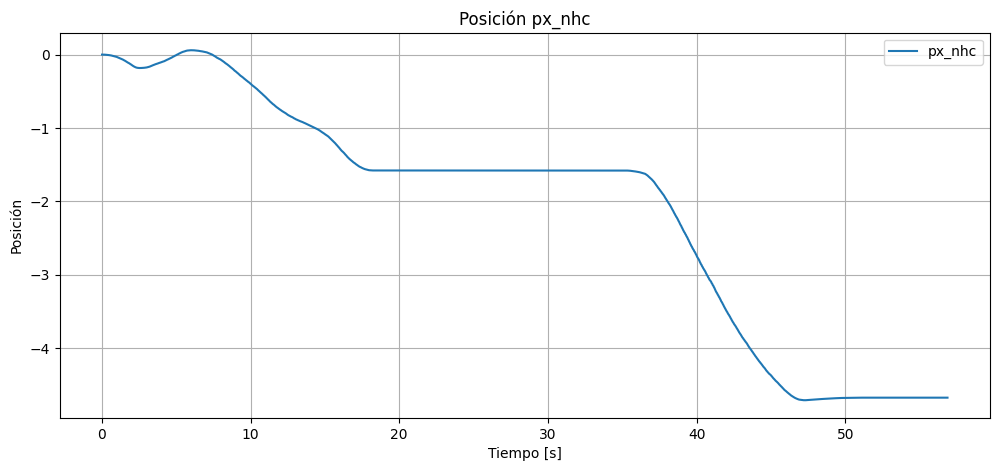

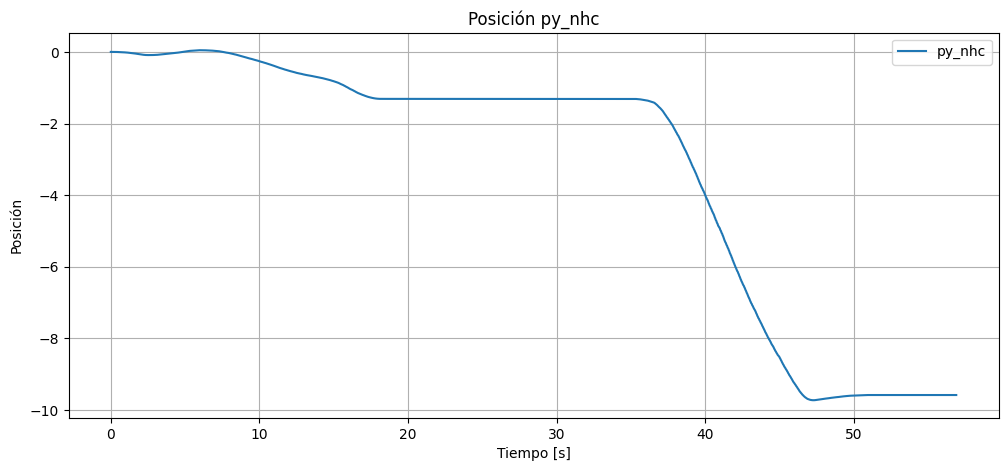

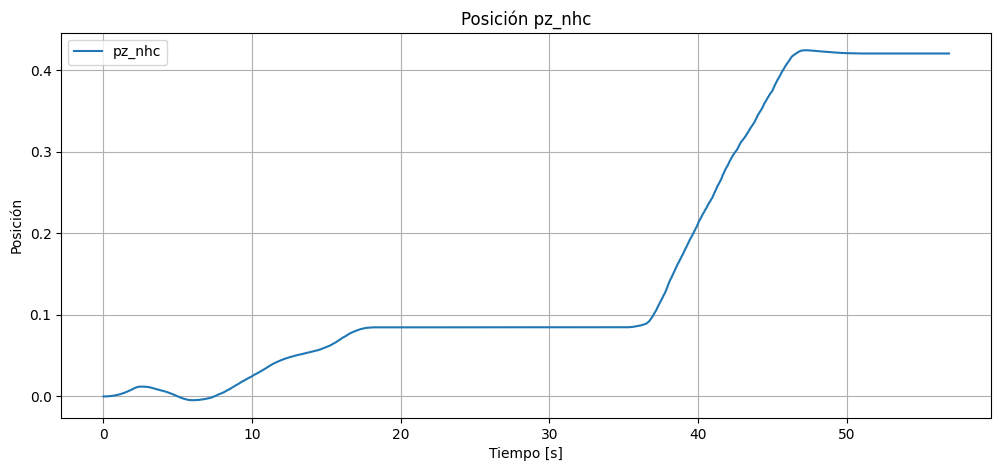

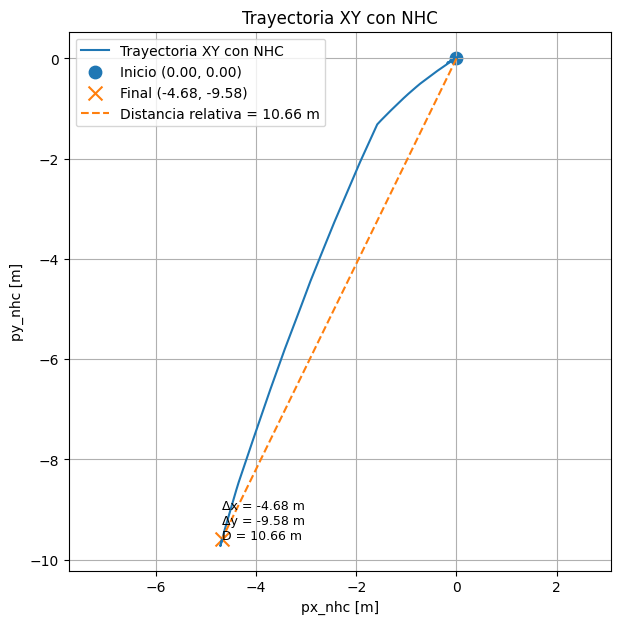

: 

In [ ]:
plot_nhc_position(data)